In [ ]:
!pip install -q --upgrade shap xgboost transformers

import warnings, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from scipy.cluster import hierarchy
warnings.filterwarnings("ignore")

import shap, xgboost as xgb
from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, r2_score

shap.initjs()
np.random.seed(42)
print(f"SHAP: {shap.__version__}\n")

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="MedHouseVal")
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

reg = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                      subsample=0.9, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
print(f"Housing regressor R² = {reg.score(X_te, y_te):.3f}")

def reg_predict(X):
    return reg.predict(np.asarray(X))

In [ ]:
print("\n" + "="*72)
print("PART 1: Explainer comparison — correctness & speed")
print("="*72)

X_sample = X_te.iloc[:25]
bg_small = shap.sample(X_tr, 50, random_state=42)

def _wrap_kernel(expl, X, bg_mean):
    vals = expl.shap_values(X, nsamples=200, silent=True)
    return shap.Explanation(values=vals, base_values=np.full(len(X), bg_mean),
                            data=X.values, feature_names=X.columns.tolist())

runs = {}

t0 = time.time(); tree_expl = shap.TreeExplainer(reg); sv_tree = tree_expl(X_sample)
runs["Tree (exact, model-aware)"] = (sv_tree, time.time() - t0)

t0 = time.time()
sv_exact = shap.Explainer(reg_predict, bg_small, algorithm="exact")(X_sample)
runs["Exact (model-agnostic)"] = (sv_exact, time.time() - t0)

t0 = time.time()
sv_perm = shap.Explainer(reg_predict, bg_small, algorithm="permutation")(X_sample)
runs["Permutation"] = (sv_perm, time.time() - t0)

t0 = time.time()
ke = shap.KernelExplainer(reg_predict, shap.sample(X_tr, 50, random_state=42).values)
sv_kern = _wrap_kernel(ke, X_sample, ke.expected_value)
runs["Kernel"] = (sv_kern, time.time() - t0)

ref = sv_tree.values.flatten()
print(f"\n{'Method':30s} {'time(s)':>8s}  {'ρ vs Tree':>10s}  {'max|Δ|':>8s}")
for name, (sv, dt) in runs.items():
    flat = sv.values.flatten()
    rho = np.corrcoef(ref, flat)[0, 1]
    err = np.abs(ref - flat).max()
    print(f"{name:30s} {dt:8.2f}  {rho:10.4f}  {err:8.4f}")
print("\nTakeaway: Tree is the only exact + fast option for tree ensembles.")
print("Exact ≈ Permutation when permutation has enough samples; Kernel is noisier and slowest.")

print("\n" + "="*72)
print("PART 2: Maskers — Independent vs Partition under correlation")
print("="*72)

corr = X_tr.corr().abs()
top_pair = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1)) \
              .stack().sort_values(ascending=False).head(3)
print("Top correlated pairs (|ρ|):")
for (a, b), v in top_pair.items():
    print(f"  {a:10s} ↔ {b:10s}  |ρ| = {v:.3f}")

masker_ind  = shap.maskers.Independent(X_tr, max_samples=100)
masker_part = shap.maskers.Partition(X_tr,  max_samples=100)
sv_ind  = shap.Explainer(reg_predict, masker_ind)(X_sample)
sv_part = shap.Explainer(reg_predict, masker_part)(X_sample)

a, b = top_pair.index[0]
print(f"\nMean |φ| for top-correlated pair ({a}, {b}):")
print(f"  Independent : {a}={np.abs(sv_ind[:,a].values).mean():.4f}   {b}={np.abs(sv_ind[:,b].values).mean():.4f}")
print(f"  Partition   : {a}={np.abs(sv_part[:,a].values).mean():.4f}   {b}={np.abs(sv_part[:,b].values).mean():.4f}")
print("Partition redistributes credit across correlated features (on-manifold semantics).")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plt.sca(axes[0]); shap.plots.bar(sv_ind, show=False);  axes[0].set_title("Independent masker")
plt.sca(axes[1]); shap.plots.bar(sv_part, show=False); axes[1].set_title("Partition masker")
plt.tight_layout(); plt.show()

In [ ]:
print("\n" + "="*72)
print("PART 3: Interaction decomposition")
print("="*72)

inter = tree_expl.shap_interaction_values(X_te.iloc[:500])
inter_abs = np.abs(inter).mean(0)
diag = np.diagonal(inter_abs).copy()
off  = inter_abs.copy(); np.fill_diagonal(off, 0)

main_share = diag.sum() / (diag.sum() + off.sum())
print(f"Total attribution mass: {main_share*100:.1f}% main effects, "
      f"{(1-main_share)*100:.1f}% interactions")

pairs = [(X.columns[i], X.columns[j], off[i, j])
         for i in range(X.shape[1]) for j in range(i+1, X.shape[1])]
pairs.sort(key=lambda t: -t[2])
print("\nTop 5 interaction pairs (mean |φ_ij|):")
for a, b, v in pairs[:5]:
    print(f"  {a:10s} × {b:10s}  →  {v:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(off, cmap="viridis")
ax.set_xticks(range(X.shape[1])); ax.set_xticklabels(X.columns, rotation=45, ha="right")
ax.set_yticks(range(X.shape[1])); ax.set_yticklabels(X.columns)
plt.colorbar(im, label="mean |φ_ij|"); plt.title("Pairwise interaction strength")
plt.tight_layout(); plt.show()

a, b, _ = pairs[0]
i, j = X.columns.get_loc(a), X.columns.get_loc(b)
xs = X_te.iloc[:500][a].values; cs = X_te.iloc[:500][b].values
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
axes[0].scatter(xs, inter[:, i, i], c=cs, s=12, cmap="coolwarm")
axes[0].set_title(f"Main effect of {a}");  axes[0].set_xlabel(a); axes[0].set_ylabel("φ_{ii}")
sc = axes[1].scatter(xs, 2*inter[:, i, j], c=cs, s=12, cmap="coolwarm")
axes[1].set_title(f"Interaction {a} × {b}"); axes[1].set_xlabel(a); axes[1].set_ylabel("2·φ_{ij}")
plt.colorbar(sc, ax=axes[1], label=b); plt.tight_layout(); plt.show()

print("\n" + "="*72)
print("PART 4: Link functions — logit vs probability space")
print("="*72)

cancer = load_breast_cancer()
Xc = pd.DataFrame(cancer.data, columns=cancer.feature_names)
yc = pd.Series(cancer.target)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.25, random_state=42, stratify=yc)

clf = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                        eval_metric="logloss", random_state=42).fit(Xc_tr, yc_tr)
print(f"AUC = {roc_auc_score(yc_te, clf.predict_proba(Xc_te)[:,1]):.3f}")

expl_logit = shap.TreeExplainer(clf)
sv_logit   = expl_logit(Xc_te)
expl_prob  = shap.TreeExplainer(clf, Xc_tr.sample(100, random_state=42),
                                model_output="probability")
sv_prob    = expl_prob(Xc_te)

print(f"\nSample 0 reconstruction (φ should sum to f - E[f]):")
print(f"  log-odds : base + Σφ = {sv_logit.base_values[0] + sv_logit.values[0].sum():+.3f}")
print(f"  prob     : base + Σφ = {sv_prob.base_values[0]  + sv_prob.values[0].sum():.3f} "
      f"(model proba = {clf.predict_proba(Xc_te.iloc[[0]])[0,1]:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plt.sca(axes[0]); shap.plots.waterfall(sv_logit[0], max_display=8, show=False); axes[0].set_title("Log-odds space")
plt.sca(axes[1]); shap.plots.waterfall(sv_prob[0],  max_display=8, show=False); axes[1].set_title("Probability space")
plt.tight_layout(); plt.show()

In [ ]:
print("\n" + "="*72)
print("PART 5: Owen values from a correlation-based feature hierarchy")
print("="*72)

D = 1 - X_tr.corr().abs().values
np.fill_diagonal(D, 0)
condensed = D[np.triu_indices_from(D, k=1)]
linkage = hierarchy.linkage(condensed, method="average")

masker_owen = shap.maskers.Partition(X_tr, clustering=linkage, max_samples=100)
sv_owen = shap.Explainer(reg_predict, masker_owen)(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
hierarchy.dendrogram(linkage, labels=X.columns.tolist(), ax=axes[0])
axes[0].set_title("Feature hierarchy (1 − |ρ|)")
plt.sca(axes[1]); shap.plots.bar(sv_owen.abs.mean(0), show=False)
axes[1].set_title("Owen values (cluster-aware)")
plt.tight_layout(); plt.show()

print("\n" + "="*72)
print("PART 6: Cohort comparison with bootstrap CIs and hypothesis tests")
print("="*72)

sv_all = tree_expl(X_te)
q1, q3 = X_te["MedInc"].quantile([0.25, 0.75])
low  = (X_te["MedInc"] <= q1).values
high = (X_te["MedInc"] >= q3).values

def boot_ci(v, B=1000, seed=0):
    rng = np.random.default_rng(seed); n = len(v)
    return np.percentile([np.abs(v[rng.integers(0, n, n)]).mean() for _ in range(B)], [2.5, 97.5])

print(f"\nLow income cohort n={low.sum()},  High income cohort n={high.sum()}")
print(f"{'Feature':12s} {'low μ|φ|':>9s} {'CI_low':>14s}   {'high μ|φ|':>10s} {'CI_high':>14s}   {'Welch p':>10s}")
for j, col in enumerate(X.columns):
    lv, hv = sv_all.values[low, j], sv_all.values[high, j]
    ci_l, ci_h = boot_ci(lv, seed=j), boot_ci(hv, seed=j+100)
    _, p = stats.ttest_ind(np.abs(lv), np.abs(hv), equal_var=False)
    star = " *" if p < 0.001 else ""
    print(f"{col:12s} {np.abs(lv).mean():9.4f} [{ci_l[0]:.3f},{ci_l[1]:.3f}]   "
          f"{np.abs(hv).mean():10.4f} [{ci_h[0]:.3f},{ci_h[1]:.3f}]   {p:10.2e}{star}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 24.0 MB/s eta 0:00:00


SHAP: 0.51.0

Housing regressor R² = 0.829

PART 1: Explainer comparison — correctness & speed

Method                          time(s)   ρ vs Tree    max|Δ|
Tree (exact, model-aware)          0.12      1.0000    0.0000
Exact (model-agnostic)             6.32      0.9598    0.4119
Permutation                        7.41      0.9603    0.3969
Kernel                             1.62      0.9595    0.4145

Takeaway: Tree is the only exact + fast option for tree ensembles.
Exact ≈ Permutation when permutation has enough samples; Kernel is noisier and slowest.

PART 2: Maskers — Independent vs Partition under correlation
Top correlated pairs (|ρ|):
  Latitude   ↔ Longitude   |ρ| = 0.924
  AveRooms   ↔ AveBedrms   |ρ| = 0.836
  MedInc     ↔ AveRooms    |ρ| = 0.336

Mean |φ| for top-correlated pair (Latitude, Longitude):
  Independent : Latitude=0.5614   Longitude=0.5588
  Partition   : Latitude=0.5637   Longitude=0.5582
Partition redistributes credit across correlated features (on-manifold s

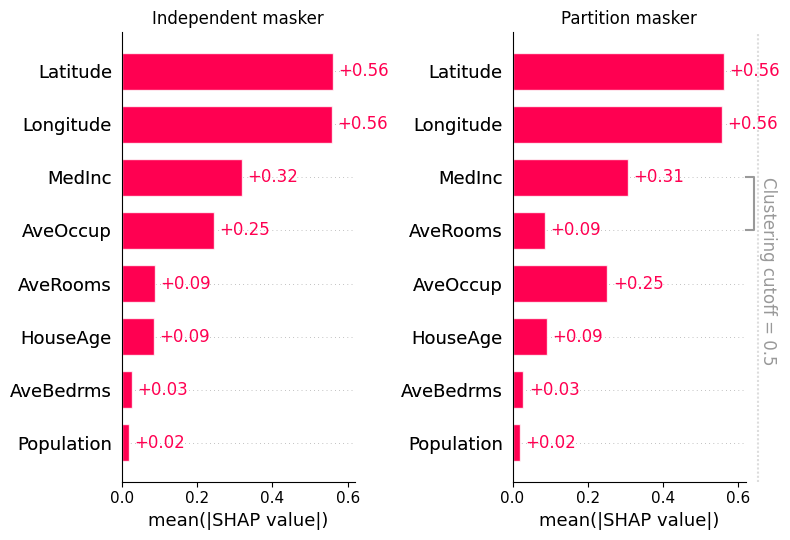


PART 3: Interaction decomposition
Total attribution mass: 61.5% main effects, 38.5% interactions

Top 5 interaction pairs (mean |φ_ij|):
  Latitude   × Longitude   →  0.1661
  MedInc     × AveOccup    →  0.0426
  MedInc     × Longitude   →  0.0283
  MedInc     × HouseAge    →  0.0283
  MedInc     × Latitude    →  0.0273


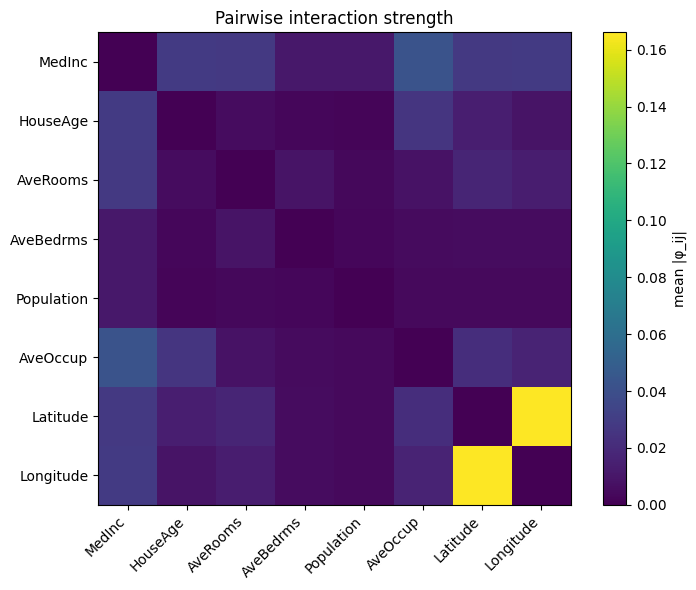

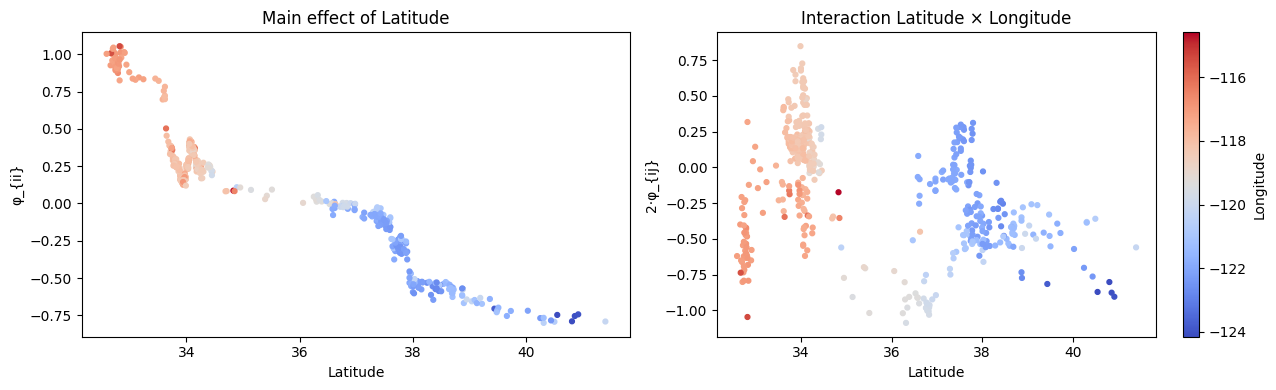


PART 4: Link functions — logit vs probability space
AUC = 0.995

Sample 0 reconstruction (φ should sum to f - E[f]):
  log-odds : base + Σφ = +6.336
  prob     : base + Σφ = 0.998 (model proba = 0.998)


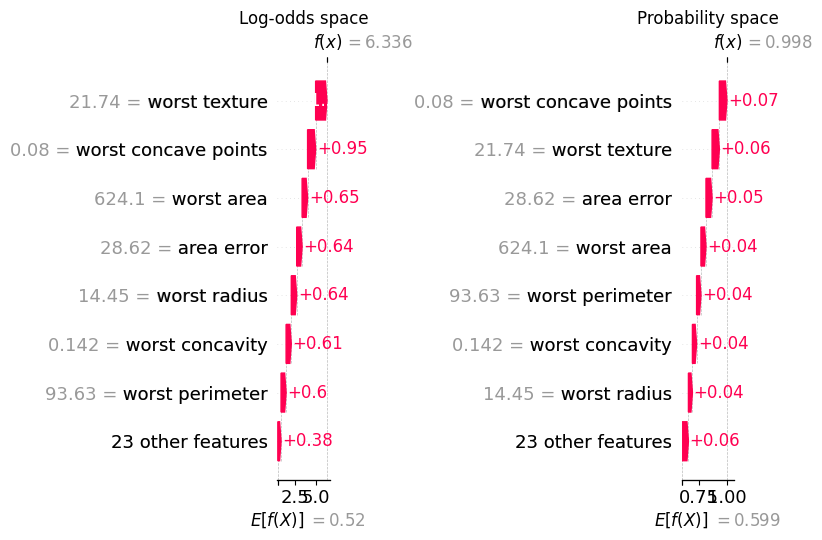


PART 5: Owen values from a correlation-based feature hierarchy


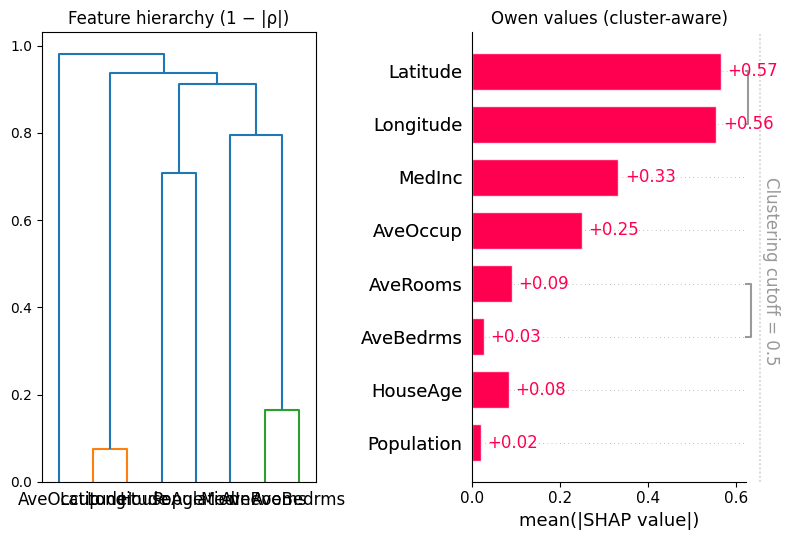


PART 6: Cohort comparison with bootstrap CIs and hypothesis tests

Low income cohort n=1032,  High income cohort n=1032
Feature       low μ|φ|         CI_low    high μ|φ|        CI_high      Welch p
MedInc          0.5571 [0.551,0.563]       0.8184 [0.782,0.854]     2.66e-39 *
HouseAge        0.0313 [0.029,0.034]       0.0928 [0.088,0.098]     2.63e-93 *
AveRooms        0.0902 [0.087,0.093]       0.1021 [0.098,0.106]     5.47e-06 *
AveBedrms       0.0263 [0.025,0.028]       0.0404 [0.038,0.042]     2.04e-27 *
Population      0.0253 [0.023,0.028]       0.0265 [0.025,0.028]     4.78e-01
AveOccup        0.1919 [0.183,0.201]       0.1919 [0.181,0.202]     9.91e-01
Latitude        0.5208 [0.504,0.538]       0.4146 [0.399,0.430]     1.84e-19 *
Longitude       0.3682 [0.350,0.386]       0.4050 [0.389,0.422]     4.59e-03

PART 7: SHAP-driven feature selection
Importance ranking:
 Latitude      0.4727
MedInc        0.4716
Longitude     0.4009
AveOccup      0.2055
AveRooms      0.0841
HouseAge 

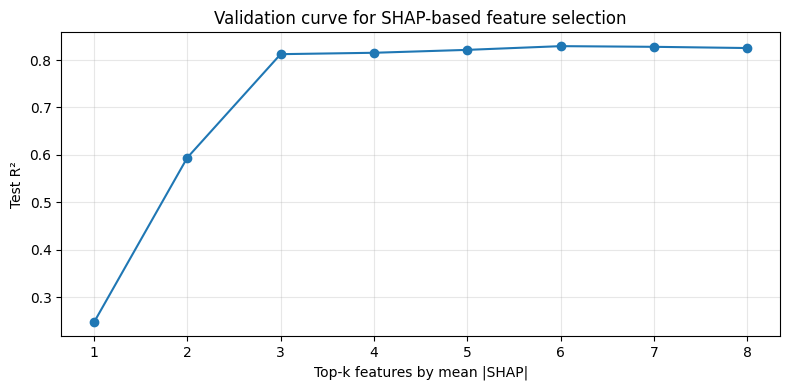


PART 8: Drift detection via KS tests on SHAP distributions
feature          KS          p   verdict
MedInc        0.925   0.00e+00   DRIFT
HouseAge      0.179   1.05e-24   DRIFT
AveRooms      0.558  1.49e-249   DRIFT
AveBedrms     0.262   6.03e-53   DRIFT
Population    0.100   5.28e-08   DRIFT
AveOccup      0.037   1.91e-01   ok
Latitude      0.170   1.78e-22   DRIFT
Longitude     0.120   2.13e-11   DRIFT

PART 9: Explaining an arbitrary black-box function
Permutation vs Exact correlation: ρ = 1.0000


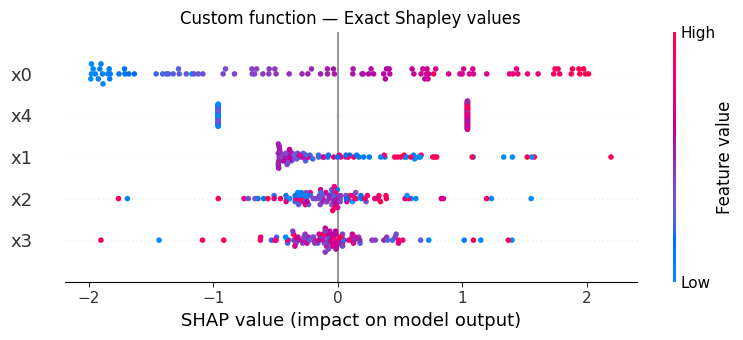

In [1]:
print("\n" + "="*72)
print("PART 7: SHAP-driven feature selection")
print("="*72)

sv_tr = tree_expl(X_tr.sample(2000, random_state=42))
rank  = pd.Series(np.abs(sv_tr.values).mean(0), index=X.columns).sort_values(ascending=False)
print("Importance ranking:\n", rank.round(4).to_string())

curve = {}
for k in range(1, len(X.columns) + 1):
    feats = rank.head(k).index.tolist()
    m = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                         random_state=42, n_jobs=-1).fit(X_tr[feats], y_tr)
    curve[k] = r2_score(y_te, m.predict(X_te[feats]))

plt.figure(figsize=(8, 4))
plt.plot(list(curve.keys()), list(curve.values()), "-o")
plt.xlabel("Top-k features by mean |SHAP|"); plt.ylabel("Test R²")
plt.title("Validation curve for SHAP-based feature selection")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\n" + "="*72)
print("PART 8: Drift detection via KS tests on SHAP distributions")
print("="*72)

ref_mask   = (X_te["MedInc"] <= X_te["MedInc"].quantile(0.7)).values
shift_mask = ~ref_mask
sv_ref   = sv_all.values[ref_mask]
sv_shift = sv_all.values[shift_mask]

print(f"{'feature':12s} {'KS':>6s} {'p':>10s}   verdict")
for j, col in enumerate(X.columns):
    ks, p = stats.ks_2samp(sv_ref[:, j], sv_shift[:, j])
    verdict = "DRIFT" if p < 0.01 else "ok"
    print(f"{col:12s} {ks:6.3f} {p:10.2e}   {verdict}")

print("\n" + "="*72)
print("PART 9: Explaining an arbitrary black-box function")
print("="*72)

def black_box(X):
    X = np.asarray(X, dtype=float)
    return (2*np.sin(X[:,0]) + 0.5*X[:,1]**2 - X[:,2]*X[:,3]
            + np.where(X[:,4] > 0, 1.0, -1.0))

X_bb = np.random.default_rng(0).standard_normal((500, 5))
names = [f"x{i}" for i in range(5)]
masker_bb = shap.maskers.Independent(X_bb, max_samples=100)

sv_perm_bb  = shap.Explainer(black_box, masker_bb, feature_names=names,
                             algorithm="permutation")(X_bb[:100])
sv_exact_bb = shap.Explainer(black_box, masker_bb, feature_names=names,
                             algorithm="exact")(X_bb[:100])
print(f"Permutation vs Exact correlation: "
      f"ρ = {np.corrcoef(sv_perm_bb.values.flatten(), sv_exact_bb.values.flatten())[0,1]:.4f}")
shap.plots.beeswarm(sv_exact_bb, show=False)
plt.title("Custom function — Exact Shapley values"); plt.tight_layout(); plt.show()